# Exercise 04 - Segmentation and Morphological Operations

**Objective:** Segment meaningful image regions and refine them using erosion, dilation, opening, and closing.

This notebook is designed to run directly in **Google Colab**. Run cells from top to bottom.

In [1]:
# Common setup for Google Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_bgr(img, title="Image", size=(8, 5)):
    """Display a BGR/OpenCV image correctly in notebook."""
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", size=(8, 5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 1: Create a noisy sample image
This image contains different objects with noise, so segmentation and morphology can be demonstrated clearly.

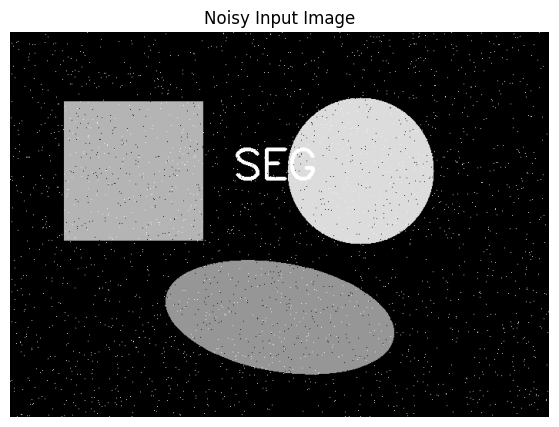

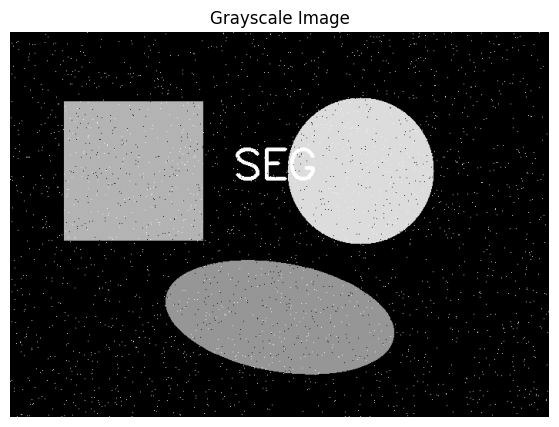

In [2]:

img = np.zeros((500, 700, 3), dtype=np.uint8)
cv2.rectangle(img, (70, 90), (250, 270), (180, 180, 180), -1)
cv2.circle(img, (455, 180), 95, (220, 220, 220), -1)
cv2.ellipse(img, (350, 370), (150, 70), 10, 0, 360, (150, 150, 150), -1)
cv2.putText(img, "SEG", (290, 190), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 255, 255), 4)

# Add salt-and-pepper noise
rng = np.random.default_rng(4)
noise_points = rng.integers([0, 0], [500, 700], size=(4500, 2))
for y, x in noise_points:
    img[y, x] = (255, 255, 255) if rng.random() > 0.5 else (0, 0, 0)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_bgr(img, "Noisy Input Image")
show_gray(gray, "Grayscale Image")


## Step 2: Thresholding
Thresholding separates foreground objects from the background.

Otsu threshold value: 0.0


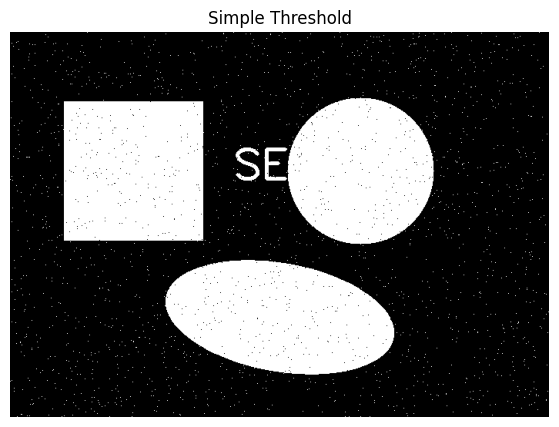

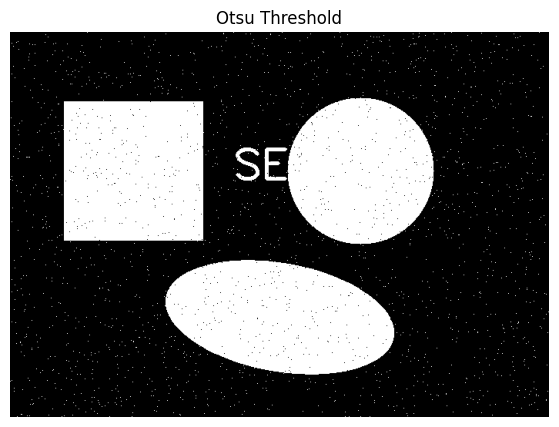

In [3]:

# Simple binary threshold
_, simple_thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

# Otsu threshold automatically selects the threshold value
otsu_value, otsu_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Otsu threshold value:", otsu_value)

show_gray(simple_thresh, "Simple Threshold")
show_gray(otsu_thresh, "Otsu Threshold")


## Step 3: Edge-based segmentation using Canny
Canny detects object boundaries/edges.

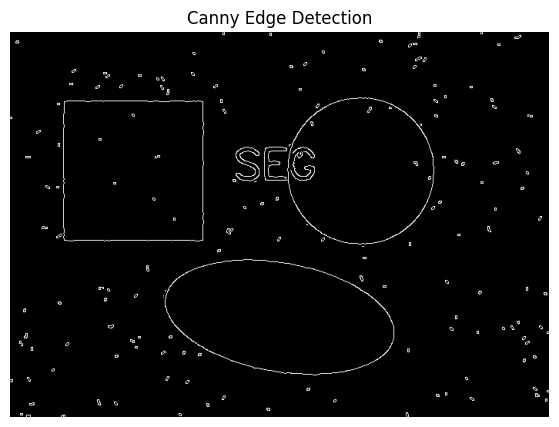

In [4]:

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 60, 150)

show_gray(edges, "Canny Edge Detection")


## Step 4: Morphological operations
Erosion shrinks white regions, dilation expands them, opening removes noise, and closing fills small gaps.

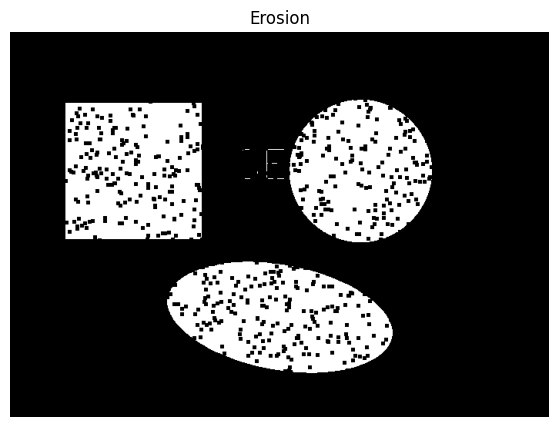

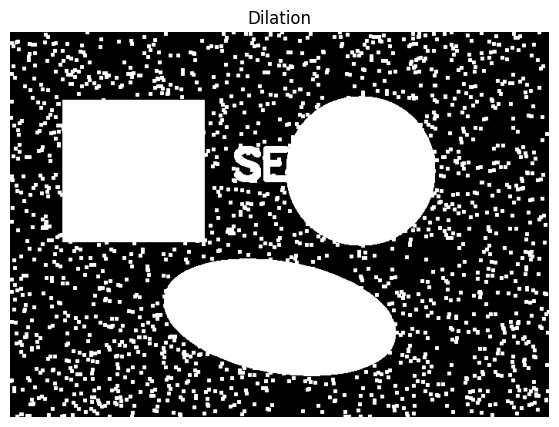

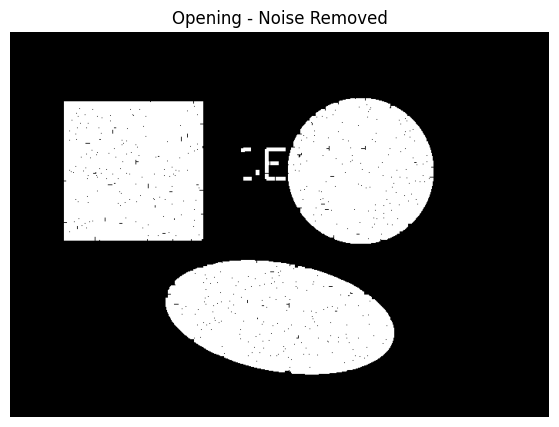

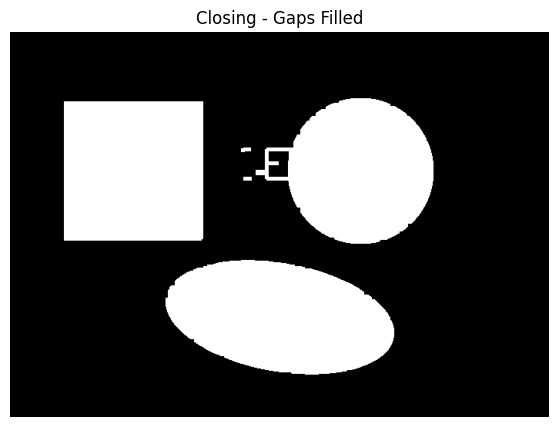

In [5]:

kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(otsu_thresh, kernel, iterations=1)
dilated = cv2.dilate(otsu_thresh, kernel, iterations=1)
opened = cv2.morphologyEx(otsu_thresh, cv2.MORPH_OPEN, kernel, iterations=1)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

show_gray(eroded, "Erosion")
show_gray(dilated, "Dilation")
show_gray(opened, "Opening - Noise Removed")
show_gray(closed, "Closing - Gaps Filled")


## Step 5: Find segmented regions using contours
Contours help identify separate objects after segmentation.

Number of segmented objects: 3


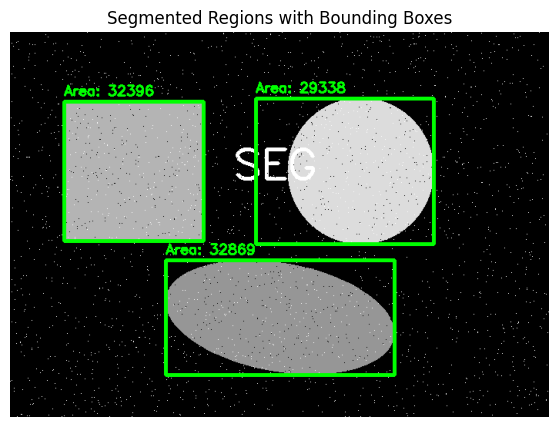

In [6]:

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()
valid_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1200:
        valid_count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(output, f"Area: {int(area)}", (x, y-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

print("Number of segmented objects:", valid_count)
show_bgr(output, "Segmented Regions with Bounding Boxes")


## Result
The image was segmented using thresholding and edges. Morphological operations cleaned the mask and helped detect object regions.